In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

# Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics._classification import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, classification_report

In [2]:
df = pd.read_csv( '../data/raw/Parkinsson disease.csv' )

In [3]:
df.drop( columns = 'name', inplace= True )

In [4]:
df

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.426,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.626,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.482,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.517,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,174.188,230.978,94.261,0.00459,0.00003,0.00263,0.00259,0.00790,0.04087,0.405,...,0.07008,0.02764,19.517,0,0.448439,0.657899,-6.538586,0.121952,2.657476,0.133050
191,209.516,253.017,89.488,0.00564,0.00003,0.00331,0.00292,0.00994,0.02751,0.263,...,0.04812,0.01810,19.147,0,0.431674,0.683244,-6.195325,0.129303,2.784312,0.168895
192,174.688,240.005,74.287,0.01360,0.00008,0.00624,0.00564,0.01873,0.02308,0.256,...,0.03804,0.10715,17.883,0,0.407567,0.655683,-6.787197,0.158453,2.679772,0.131728
193,198.764,396.961,74.904,0.00740,0.00004,0.00370,0.00390,0.01109,0.02296,0.241,...,0.03794,0.07223,19.020,0,0.451221,0.643956,-6.744577,0.207454,2.138608,0.123306


In [5]:
df.columns

Index(['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)',
       'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP',
       'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5',
       'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'status', 'RPDE', 'DFA',
       'spread1', 'spread2', 'D2', 'PPE'],
      dtype='object')

In [6]:
X = df.drop( columns = 'status' )
y = df['status']

In [7]:
X

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE
0,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.426,...,0.02971,0.06545,0.02211,21.033,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.626,...,0.04368,0.09403,0.01929,19.085,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.482,...,0.03590,0.08270,0.01309,20.651,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.517,...,0.03772,0.08771,0.01353,20.644,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,...,0.04465,0.10470,0.01767,19.649,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,174.188,230.978,94.261,0.00459,0.00003,0.00263,0.00259,0.00790,0.04087,0.405,...,0.02745,0.07008,0.02764,19.517,0.448439,0.657899,-6.538586,0.121952,2.657476,0.133050
191,209.516,253.017,89.488,0.00564,0.00003,0.00331,0.00292,0.00994,0.02751,0.263,...,0.01879,0.04812,0.01810,19.147,0.431674,0.683244,-6.195325,0.129303,2.784312,0.168895
192,174.688,240.005,74.287,0.01360,0.00008,0.00624,0.00564,0.01873,0.02308,0.256,...,0.01667,0.03804,0.10715,17.883,0.407567,0.655683,-6.787197,0.158453,2.679772,0.131728
193,198.764,396.961,74.904,0.00740,0.00004,0.00370,0.00390,0.01109,0.02296,0.241,...,0.01588,0.03794,0.07223,19.020,0.451221,0.643956,-6.744577,0.207454,2.138608,0.123306


In [8]:
y

0      1
1      1
2      1
3      1
4      1
      ..
190    0
191    0
192    0
193    0
194    0
Name: status, Length: 195, dtype: int64

In [9]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

# Model Selection

## [1] KNN

In [10]:
knn_model = KNeighborsClassifier(  )

In [11]:
knn_model.fit( X_train, y_train )

KNeighborsClassifier()

In [38]:
X_train

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE
5,120.552,131.162,113.787,0.00968,0.00008,0.00463,0.00750,0.01388,0.04701,0.456,...,0.03243,0.06985,0.01222,21.378,0.415564,0.825069,-4.242867,0.299111,2.187560,0.357775
135,110.453,127.611,105.554,0.00494,0.00004,0.00244,0.00315,0.00731,0.04128,0.379,...,0.03316,0.06688,0.02529,17.707,0.653427,0.706687,-5.333619,0.322044,2.631793,0.228319
122,138.190,203.522,83.340,0.00704,0.00005,0.00406,0.00398,0.01218,0.04479,0.441,...,0.03220,0.07761,0.01968,18.305,0.538016,0.741480,-5.418787,0.160267,2.090438,0.229892
167,260.105,264.919,237.303,0.00339,0.00001,0.00205,0.00186,0.00616,0.02030,0.197,...,0.01367,0.03557,0.00910,21.083,0.440988,0.628058,-7.517934,0.160414,1.881767,0.075587
85,180.978,200.125,155.495,0.00406,0.00002,0.00220,0.00244,0.00659,0.03852,0.331,...,0.02877,0.06321,0.02782,16.176,0.583574,0.727747,-5.657899,0.315903,3.098256,0.200423
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,155.078,163.736,144.148,0.00168,0.00001,0.00068,0.00092,0.00204,0.01064,0.097,...,0.00928,0.01567,0.00233,29.746,0.334171,0.677930,-6.981201,0.184550,2.129924,0.106802
14,152.845,163.305,75.836,0.00294,0.00002,0.00121,0.00149,0.00364,0.01828,0.158,...,0.01246,0.03191,0.00609,24.922,0.474791,0.654027,-6.105098,0.203653,2.125618,0.170100
92,148.272,164.989,142.299,0.00459,0.00003,0.00250,0.00256,0.00750,0.04190,0.383,...,0.03051,0.07150,0.01914,18.780,0.454444,0.734504,-5.952058,0.087840,2.344336,0.186489
179,148.143,155.982,135.041,0.00392,0.00003,0.00204,0.00231,0.00612,0.01450,0.131,...,0.01263,0.02175,0.00540,23.683,0.398499,0.778349,-5.711205,0.240875,2.845109,0.192730


In [12]:
y_train

5      1
135    1
122    1
167    0
85     1
      ..
106    1
14     1
92     1
179    1
102    1
Name: status, Length: 156, dtype: int64

In [39]:
y_pred_train = knn_model.predict( X_train )
y_pred_train

array([1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0,
       1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1])

In [40]:
acc_train = accuracy_score( y_true= y_train, y_pred= y_pred_train) * 100
print( f'Training Acc: { acc_train }' )

Training Acc: 89.74358974358975


#### Compute model predictions (test)

In [41]:
y_pred_test = knn_model.predict( X_test )
y_pred_test

array([1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1])

In [42]:
conf_mat = confusion_matrix( y_test, y_pred_test )   # 2D
conf_mat

array([[ 3,  4],
       [ 3, 29]])

#### Visualize Confusion Matrix

### annot --> annotation

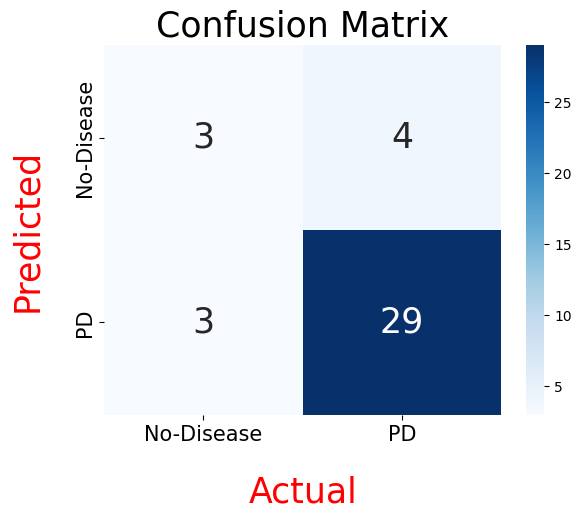

In [43]:
sns.heatmap( conf_mat, cmap = 'Blues', annot= True,
             annot_kws= { 'fontsize' : 25 });
plt.title( 'Confusion Matrix', fontsize = 25 );
plt.xticks( [0.5, 1.5], labels = [ 'No-Disease', 'PD' ], fontsize = 15 ); plt.xlabel( 'Actual', fontsize = 25, labelpad= 22, color = 'red' )
plt.yticks( [ 0.5, 1.5 ], labels = [ 'No-Disease', 'PD' ], fontsize = 15  ); plt.ylabel( 'Predicted', fontsize = 25, labelpad= 22, color = 'red' );

In [44]:
acc_test = ( 3 + 29 ) / ( 3 + 4 + 3 + 29 ) * 100
acc_test

82.05128205128204

In [19]:
accuracy_score( y_test, y_pred_test )

0.8205128205128205

In [45]:
print( f'Training Acc for KNN : { acc_train }' )
print( f'Testing Acc for KNN : { acc_test }'  )

Training Acc for KNN : 89.74358974358975
Testing Acc for KNN : 82.05128205128204


In [21]:
X_train

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE
5,120.552,131.162,113.787,0.00968,0.00008,0.00463,0.00750,0.01388,0.04701,0.456,...,0.03243,0.06985,0.01222,21.378,0.415564,0.825069,-4.242867,0.299111,2.187560,0.357775
135,110.453,127.611,105.554,0.00494,0.00004,0.00244,0.00315,0.00731,0.04128,0.379,...,0.03316,0.06688,0.02529,17.707,0.653427,0.706687,-5.333619,0.322044,2.631793,0.228319
122,138.190,203.522,83.340,0.00704,0.00005,0.00406,0.00398,0.01218,0.04479,0.441,...,0.03220,0.07761,0.01968,18.305,0.538016,0.741480,-5.418787,0.160267,2.090438,0.229892
167,260.105,264.919,237.303,0.00339,0.00001,0.00205,0.00186,0.00616,0.02030,0.197,...,0.01367,0.03557,0.00910,21.083,0.440988,0.628058,-7.517934,0.160414,1.881767,0.075587
85,180.978,200.125,155.495,0.00406,0.00002,0.00220,0.00244,0.00659,0.03852,0.331,...,0.02877,0.06321,0.02782,16.176,0.583574,0.727747,-5.657899,0.315903,3.098256,0.200423
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,155.078,163.736,144.148,0.00168,0.00001,0.00068,0.00092,0.00204,0.01064,0.097,...,0.00928,0.01567,0.00233,29.746,0.334171,0.677930,-6.981201,0.184550,2.129924,0.106802
14,152.845,163.305,75.836,0.00294,0.00002,0.00121,0.00149,0.00364,0.01828,0.158,...,0.01246,0.03191,0.00609,24.922,0.474791,0.654027,-6.105098,0.203653,2.125618,0.170100
92,148.272,164.989,142.299,0.00459,0.00003,0.00250,0.00256,0.00750,0.04190,0.383,...,0.03051,0.07150,0.01914,18.780,0.454444,0.734504,-5.952058,0.087840,2.344336,0.186489
179,148.143,155.982,135.041,0.00392,0.00003,0.00204,0.00231,0.00612,0.01450,0.131,...,0.01263,0.02175,0.00540,23.683,0.398499,0.778349,-5.711205,0.240875,2.845109,0.192730


In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

## [1] ~ Try Scaling with KNN

In [23]:
knn_pipeline = Pipeline([
    ( 'Scaling', StandardScaler() ),
    ( 'KNN-Model', KNeighborsClassifier() )
])
knn_pipeline

Pipeline(steps=[('Scaling', StandardScaler()),
                ('KNN-Model', KNeighborsClassifier())])

In [24]:
#knn_pipeline.fit( X_train, y_train )


In [25]:
'''acc_train = knn_pipeline.score( X_train, y_train ) * 100
acc_test = knn_pipeline.score( X_test, y_test ) * 100

print( f'Training Acc for KNN-Pipeline: { acc_train }' )
print( f'Testing Acc for KNN-Pipeline: { acc_test }' )'''

"acc_train = knn_pipeline.score( X_train, y_train ) * 100\nacc_test = knn_pipeline.score( X_test, y_test ) * 100\n\nprint( f'Training Acc for KNN-Pipeline: { acc_train }' )\nprint( f'Testing Acc for KNN-Pipeline: { acc_test }' )"

In [26]:
from colorama import Fore;     print( Fore.CYAN + 'sdsdsds' )

sdsdsds


In [27]:
def evaluate_classifier( model, model_name, X_train ,X_test, y_train, y_test ) :
    
    model.fit( X_train, y_train )     # Training
    y_pred = model.predict( X_test )
    print( model_name + ' :' + '\n' )
    
    acc_train = model.score( X_train, y_train ) * 100; acc_train = round( acc_train, 2 )
    
    acc_test = model.score( X_test, y_test ) * 100;    acc_test = round( acc_test, 2 )
    precision = precision_score( y_test, y_pred ) * 100
    recall = recall_score( y_test, y_pred ) * 100
    f1 = f1_score( y_test, y_pred ) * 100
    report = classification_report( y_test, y_pred )
    
    print( f'Training Acc : { acc_train }%' )
    print( f'Testing Acc : { acc_test }%' )
    print( Fore.RED + f'Recall: {recall}%' )
    print( Fore.WHITE + f'Precision: {precision}%' )
    print( Fore.WHITE + f'F1-Score: {f1}%' )
    print( Fore.WHITE + report )
    

In [28]:
evaluate_classifier( knn_pipeline, 'KNN with Scaling', X_train ,X_test, y_train, y_test ) # lazy model 

KNN with Scaling :

Training Acc : 94.87%
Testing Acc : 94.87%
Recall: 100.0%
Precision: 94.11764705882352%
F1-Score: 96.96969696969697%
              precision    recall  f1-score   support

           0       1.00      0.71      0.83         7
           1       0.94      1.00      0.97        32

    accuracy                           0.95        39
   macro avg       0.97      0.86      0.90        39
weighted avg       0.95      0.95      0.95        39



In [29]:
10 /11

0.9090909090909091

## [2] logistic Regression

### logit

In [30]:
prediction = 0.5 # output 

logit = 1 / ( 1 + 2.71 ** -0.5 )
logit

0.6221007232073492

In [31]:
from sklearn.linear_model import LogisticRegressionCV   # cross validation

In [32]:
log_reg_pipe = Pipeline(
    [
        ( 'Scaling', StandardScaler() ),
        ( 'Logistic Regression Model', LogisticRegressionCV( max_iter= 200 ) )
    ]
)

In [33]:
evaluate_classifier( log_reg_pipe, 'LogisticRegressionCV with Scaling', X_train ,X_test, y_train, y_test )

LogisticRegressionCV with Scaling :

Training Acc : 87.82%
Testing Acc : 92.31%
Recall: 100.0%
Precision: 91.42857142857143%
F1-Score: 95.52238805970148%
              precision    recall  f1-score   support

           0       1.00      0.57      0.73         7
           1       0.91      1.00      0.96        32

    accuracy                           0.92        39
   macro avg       0.96      0.79      0.84        39
weighted avg       0.93      0.92      0.91        39



## [3] SVC

In [34]:
from sklearn.svm import SVC

In [35]:
svc_pipe = Pipeline([
    ( 'Scaling', StandardScaler() ),
    ( 'SVC', SVC() )
])

In [36]:
evaluate_classifier( svc_pipe, 'SVC with Scaling', X_train ,X_test, y_train, y_test )

SVC with Scaling :

Training Acc : 89.1%
Testing Acc : 89.74%
Recall: 100.0%
Precision: 88.88888888888889%
F1-Score: 94.11764705882352%
              precision    recall  f1-score   support

           0       1.00      0.43      0.60         7
           1       0.89      1.00      0.94        32

    accuracy                           0.90        39
   macro avg       0.94      0.71      0.77        39
weighted avg       0.91      0.90      0.88        39

